# Grammar Scoring Engine for Spoken English

Predict a 0–5 grammar score for 45–60 s spoken answers (769 train, 216 test clips). Metrics: RMSE and Pearson correlation.

**Approach.** Two complementary views of each clip:
- **What was said:** a verbatim Whisper transcript, turned into rubric-aligned features (accuracy, complexity, completeness, disfluency, fluency) and a RoBERTa text embedding.
- **How it was said:** audio embeddings from two pretrained speech models, WavLM-large (trained on sound) and Whisper-large-v3's encoder (trained to recognise words).

Ridge regressions and LightGBM models are trained on these inputs; the final prediction is the equal-weight average of four models. Each step below is evaluated on the same cross-validation folds before the next is added.

**Inputs** (from the other notebooks): `transcripts_*.parquet` (01), `audio_embeddings_wavlm_large.npz` (02), `whisper_embeddings_large_v3.npz` (03).

**Result:** public leaderboard RMSE **0.3882**. Cross-validated metrics and the compulsory training RMSE are in Section 9.

## 1. Setup

In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from lightgbm import LGBMRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED = 42
N_FOLDS = 5
INPUT_ROOT = Path("/kaggle/input")
OUT_DIR = Path("/kaggle/working")
SHORT_CLIP_MAX_SEC = 50
PAUSE_MIN_SEC, LONG_PAUSE_SEC = 0.25, 1.0
LAYER_TOLERANCE = 0.01
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_one(pattern):
    found = sorted(p for p in INPUT_ROOT.rglob(pattern) if "_DEBUG" not in p.name)
    assert len(found) == 1, f"Expected exactly one {pattern} under {INPUT_ROOT}, found: {found}"
    return found[0]

## 2. Data
Labels come from the competition CSVs, transcripts from notebook 01. Train and test share 212 file names, so clips are identified by split + file name.

In [2]:
DATA_DIR = find_one("train.csv").parent
train_csv = pd.read_csv(DATA_DIR / "train.csv", dtype={"filename": str})
test_csv = pd.read_csv(DATA_DIR / "test.csv", dtype={"filename": str})
for name, df in [("train.csv", train_csv), ("test.csv", test_csv)]:
    assert list(df.columns) == ["filename", "label"], f"{name} has columns {list(df.columns)}"

data = pd.concat([train_csv.assign(split="train"), test_csv.assign(split="test")], ignore_index=True)
data["file_id"] = data["filename"].map(lambda s: Path(s).stem)
assert not data.duplicated(["split", "file_id"]).any()

tx_cols = ["split", "file_id", "duration_sec", "transcript", "words_json", "mean_avg_logprob", "max_no_speech_prob"]
tx = pd.read_parquet(find_one("transcripts_*.parquet"))[tx_cols]
tx["file_id"] = tx["file_id"].astype(str)
tx["transcript"] = tx["transcript"].fillna("").astype(str)
data = data.merge(tx, on=["split", "file_id"], how="left", validate="one_to_one")
assert data["words_json"].notna().all(), "Some clips have no transcript"
data["dur_group"] = np.where(data["duration_sec"] <= SHORT_CLIP_MAX_SEC, "short", "long")

is_train = (data["split"] == "train").to_numpy()
is_test = ~is_train
y = data.loc[is_train, "label"].to_numpy(dtype=float)
print(data["split"].value_counts().to_string())

split
train    769
test     216


**Two properties of the data shape the design:**
- **Label 0** is not defined by the rubric (1–5). These 37 clips are as long as the others, so they most likely mark recordings that could not be scored.
- **Clip length differs between splits.** Train is mostly ~60 s clips, test mostly ~45 s clips, and short clips score lower and less widely in train. Every feature is therefore a rate or proportion, and validation is also reported for short clips.

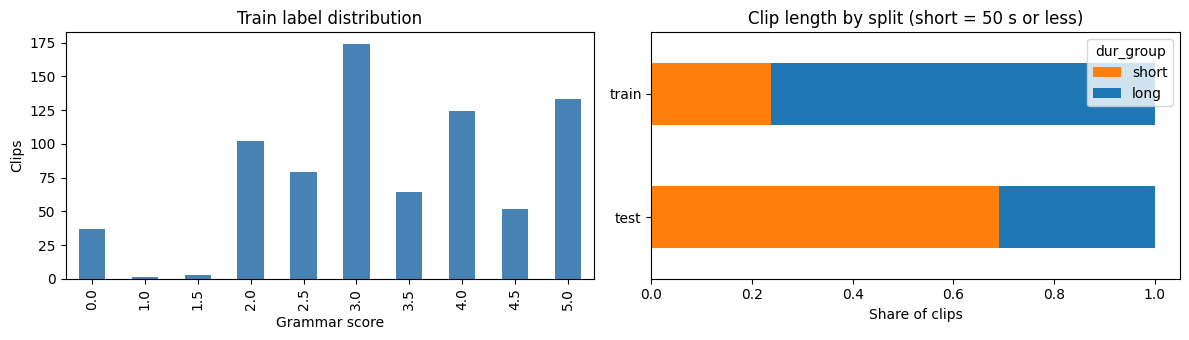

,count,mean,std
dur_group,,,
long,587,3.39,1.3
short,182,3.06,1.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
data.loc[is_train, "label"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Train label distribution", xlabel="Grammar score", ylabel="Clips")
mix = pd.crosstab(data["split"], data["dur_group"], normalize="index")[["short", "long"]]
mix.plot.barh(stacked=True, ax=axes[1], color=["tab:orange", "tab:blue"])
axes[1].set(title="Clip length by split (short = 50 s or less)", xlabel="Share of clips", ylabel="")
plt.tight_layout()
plt.show()
display(data[is_train].groupby("dur_group")["label"].agg(["count", "mean", "std"]).round(2))

## 3. Validation
5-fold cross-validation stratified on score band × clip length, so every fold has the same mix of both. All models use the same folds, so their scores are directly comparable. Reported CV metrics come from out-of-fold predictions. Anything fitted (scaling, ridge strength, models) is fitted inside the training part of each fold.

Metrics: **RMSE** and **Pearson** (the competition metrics), **Spearman** (ranking), **MAE** (typical error in points) and **R²** (share of score variance explained). The final model is also measured the way rater agreement is usually reported: **quadratic weighted kappa** and **exact / ±0.5 / ±1 agreement** on the half-point score grid.

In [4]:
band = pd.cut(y, bins=[-0.1, 1.75, 2.75, 3.75, 4.75, 5.1], labels=["0-1.5", "2-2.5", "3-3.5", "4-4.5", "5"]).astype(str)
strata = (pd.Series(band, dtype=str) + "_" + data.loc[is_train, "dur_group"].to_numpy()).to_numpy()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The least populated class")
    FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(np.zeros(len(y)), strata))

LGB_PARAMS = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=20, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, verbose=-1)
RIDGE_ALPHAS = np.logspace(0, 6, 25)

def make_model(kind):
    if kind == "ridge":
        return make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    return LGBMRegressor(**LGB_PARAMS)

def cv_predict(kind, X):
    oof = np.zeros(len(y))
    for tr, va in FOLDS:
        oof[va] = make_model(kind).fit(X[tr], y[tr]).predict(X[va])
    return np.clip(oof, 0, 5)

def score(t, p):
    return {"RMSE": float(np.sqrt(np.mean((t - p) ** 2))), "MAE": float(np.mean(np.abs(t - p))),
            "R2": float(1 - np.sum((t - p) ** 2) / np.sum((t - t.mean()) ** 2)),
            "Pearson": float(pearsonr(t, p)[0]), "Spearman": float(spearmanr(t, p)[0])}

def agreement(t, p):
    grid_t, grid_p = np.round(2 * t).astype(int), np.round(2 * np.clip(p, 0, 5)).astype(int)
    return {"QWK": float(cohen_kappa_score(grid_t, grid_p, weights="quadratic", labels=list(range(11)))),
            "Exact (0.5 grid)": float(np.mean(grid_t == grid_p)),
            "Within ±0.5": float(np.mean(np.abs(t - p) <= 0.5)), "Within ±1.0": float(np.mean(np.abs(t - p) <= 1.0))}

def blend(preds):
    return np.clip(np.mean([np.clip(p, 0, 5) for p in preds], axis=0), 0, 5)

RESULTS = {}
def record(name, oof):
    RESULTS[name] = score(y, oof)
    print(f"{name}: CV RMSE {RESULTS[name]['RMSE']:.4f} | Pearson {RESULTS[name]['Pearson']:.4f}")

baseline = np.zeros(len(y))
for tr, va in FOLDS:
    baseline[va] = y[tr].mean()
record("Baseline: predict the training mean", baseline)

Baseline: predict the training mean: CV RMSE 1.2382 | Pearson -0.0096


## 4. Step 1: rubric-aligned features from the transcript
The rubric scores four qualities: **accuracy**, **complexity**, **sentence completeness** and **self-correction**. Raters are also influenced by **fluency**. Each group below measures one of these; a last group flags recordings with little usable speech (label 0).

Fillers and immediate repetitions are counted on the verbatim transcript, then removed from a cleaned copy that feeds the grammar tools, so a hesitation such as "and, and, and" is not also counted as a grammar error.

In [5]:
FILLER_CORE = r"(?:u+h+m*|u+m+|h+m+|e+r+m*|a+h+)"
FILLER_TOKEN_RE = re.compile(rf"^{FILLER_CORE}$", re.IGNORECASE)
FILLER_RE = re.compile(rf"(?:,\s*)?\b{FILLER_CORE}\b[,.]?\s*", re.IGNORECASE)
WORD_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z]+)?")
REPEAT2_RE = re.compile(r"\b(\w+\s+\w+)(?:[\s,]+\1\b)+", re.IGNORECASE)
REPEAT1_RE = re.compile(r"\b(\w+)(?:[\s,]+\1\b)+", re.IGNORECASE)

def clean_text(text):
    t = FILLER_RE.sub(" ", text)
    t = re.sub(r"\.{2,}|…", " ", t)
    t = REPEAT2_RE.sub(r"\1", t)
    t = REPEAT1_RE.sub(r"\1", t)
    t = re.sub(r"\s+([,.!?])", r"\1", t)
    t = re.sub(r"([,.!?])(?:\s*,)+", r"\1", t)
    t = re.sub(r"\s{2,}", " ", t).strip()
    return re.sub(r"^[,.\s]+", "", t)

def disfluency_features(text):
    tokens = [t.lower() for t in WORD_RE.findall(text)]
    if not tokens:
        return {"filler_per100": np.nan, "repetition_per100": np.nan}
    words = [t for t in tokens if not FILLER_TOKEN_RE.match(t)]
    rep1 = sum(words[i] == words[i - 1] for i in range(1, len(words)))
    rep2 = sum(words[i:i + 2] == words[i - 2:i] and words[i - 1] != words[i - 2] for i in range(2, len(words) - 1))
    return {"filler_per100": 100 * (len(tokens) - len(words)) / len(tokens),
            "repetition_per100": 100 * (rep1 + rep2) / len(tokens)}

FLUENCY_KEYS = ["words_per_clip_min", "speech_rate_wpm", "mean_length_of_run", "pauses_per_min",
                "long_pauses_per_min", "mean_pause_sec"]

def fluency_features(words_json, duration_sec, transcript):
    words = [w for w in json.loads(words_json) if WORD_RE.search(w[0] or "")]
    n = len(words)
    if n == 0 and WORD_RE.search(transcript):
        return {k: np.nan for k in FLUENCY_KEYS}  # transcript without word timings: fluency unknown, not zero
    out = {k: np.nan for k in FLUENCY_KEYS}
    out["words_per_clip_min"] = 60 * n / duration_sec if duration_sec > 0 else np.nan
    if n < 2:
        return out
    starts = np.array([w[1] for w in words], dtype=float)
    ends = np.array([w[2] for w in words], dtype=float)
    speaking = ends[-1] - starts[0]
    if speaking <= 0:
        return out
    gaps = np.clip(starts[1:] - ends[:-1], 0, None)
    pauses = gaps[gaps >= PAUSE_MIN_SEC]
    out.update({"speech_rate_wpm": 60 * n / speaking, "mean_length_of_run": n / (len(pauses) + 1),
                "pauses_per_min": 60 * len(pauses) / speaking,
                "long_pauses_per_min": 60 * int((gaps >= LONG_PAUSE_SEC).sum()) / speaking,
                "mean_pause_sec": float(pauses.mean()) if len(pauses) else 0.0})
    return out

demo = "Um, so the, the market is, uh, very crowded and, and, and I think, I think people... people is coming."
print("verbatim:", demo)
print("cleaned: ", clean_text(demo))
data["clean_text"] = data["transcript"].map(clean_text)
disfl = pd.DataFrame([disfluency_features(t) for t in data["transcript"]])
flu = pd.DataFrame([fluency_features(w, d, t) for w, d, t in zip(data["words_json"], data["duration_sec"], data["transcript"])])
no_timings = [json.loads(w) == [] and bool(WORD_RE.search(t)) for w, t in zip(data["words_json"], data["transcript"])]
print("Clips with a transcript but no word timings:", data.loc[no_timings, "file_id"].tolist())

verbatim: Um, so the, the market is, uh, very crowded and, and, and I think, I think people... people is coming.
cleaned:  so the market is very crowded and I think people is coming.
Clips with a transcript but no word timings: ['audio_709']


**Complexity and completeness (spaCy).** Subordinate clauses mark complex grammar; coordination ("and", "so") is typical of simpler, chained speech; parse depth measures nesting; verb-tag entropy measures the variety of verb forms. Fragments are sentences without a finite verb; dangling ends finish on a conjunction, preposition or article.

In [6]:
import spacy

try:
    nlp = spacy.load("en_core_web_sm", disable=["ner"])
except OSError:
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["ner"])

VERB_TAGS = {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ", "MD"}
FINITE_TAGS = {"VBD", "VBP", "VBZ", "MD"}
SUB_DEPS = {"advcl", "ccomp", "acl", "relcl", "csubj", "csubjpass"}
DANGLING_POS = {"CCONJ", "SCONJ", "ADP", "DET"}
SPACY_KEYS = ["mean_sent_len", "sub_per100", "sub_clause_ratio", "coord_per100", "mean_tree_depth",
              "verb_tag_entropy", "modal_per100", "passive_per100", "fragment_rate", "dangling_end_rate"]

def spacy_features(doc):
    n = sum(t.is_alpha for t in doc)
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    if n == 0 or not sents:
        return {k: np.nan for k in SPACY_KEYS}
    n_sub = sum(t.dep_ in SUB_DEPS for t in doc)
    n_main = sum(t.dep_ == "ROOT" or (t.dep_ == "conj" and t.pos_ in ("VERB", "AUX")) for t in doc)
    verb_tags = [t.tag_ for t in doc if t.tag_ in VERB_TAGS]
    p = pd.Series(verb_tags).value_counts(normalize=True).to_numpy()
    return {
        "mean_sent_len": n / len(sents),
        "sub_per100": 100 * n_sub / n,
        "sub_clause_ratio": n_sub / (n_sub + n_main) if n_sub + n_main else np.nan,
        "coord_per100": 100 * sum(t.dep_ == "cc" for t in doc) / n,
        "mean_tree_depth": float(np.mean([max(len(list(t.ancestors)) for t in s) for s in sents])),
        "verb_tag_entropy": float(-(p * np.log(p)).sum()) if verb_tags else np.nan,
        "modal_per100": 100 * sum(t.tag_ == "MD" for t in doc) / n,
        "passive_per100": 100 * sum(t.dep_ == "auxpass" for t in doc) / n,
        "fragment_rate": float(np.mean([not any(t.tag_ in FINITE_TAGS for t in s) for s in sents])),
        "dangling_end_rate": float(np.mean([[t for t in s if t.is_alpha][-1].pos_ in DANGLING_POS for s in sents])),
    }

docs = list(tqdm(nlp.pipe(data["clean_text"], batch_size=32), total=len(data), desc="spaCy"))
syn = pd.DataFrame([spacy_features(doc) for doc in docs])

spaCy:   0%|          | 0/985 [00:00<?, ?it/s]

**Accuracy (CoLA classifier).** A RoBERTa model fine-tuned on CoLA (sentences labelled grammatical or not) scores short pieces of the cleaned transcript: spaCy sentences, with sentences over 30 words cut at commas or into 30-word windows (Whisper punctuates run-on speech loosely). Per clip: the mean probability of being grammatical, and the share of pieces below 0.5. The output column meaning "grammatical" is identified from probe sentences, not from label names.

LanguageTool error rates were used here first; they detected no error in most transcripts (median 0) and were replaced (see Section 10).

In [7]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

COLA_MODEL = "textattack/roberta-base-CoLA"
MAX_PIECE_WORDS = 30
cola_tok = AutoTokenizer.from_pretrained(COLA_MODEL)
cola_model = AutoModelForSequenceClassification.from_pretrained(COLA_MODEL).to(DEVICE).eval()

@torch.no_grad()
def cola_probs(texts, batch_size=64):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = cola_tok(texts[i:i + batch_size], padding=True, truncation=True, max_length=128,
                         return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(cola_model(**batch).logits.float(), dim=-1).cpu().numpy())
    return np.vstack(out) if out else np.zeros((0, 2))

GOOD = ["The cat sat on the mat.", "She has two brothers.", "They went to the market yesterday."]
BAD = ["He go to school yesterday.", "She have two cat.", "The people is coming."]
diff = cola_probs(GOOD).mean(axis=0) - cola_probs(BAD).mean(axis=0)
ACCEPTABLE = int(np.argmax(diff))
assert diff[ACCEPTABLE] > 0.2, "The CoLA model does not separate grammatical from ungrammatical probes"

def normalise_piece(text):
    text = text.strip().rstrip(",;:").strip()
    if text and text[-1] not in ".!?":
        text += "."
    return text[:1].upper() + text[1:]

def split_into_pieces(doc):
    pieces = []
    for sent in doc.sents:
        if len(sent.text.split()) <= MAX_PIECE_WORDS:
            pieces.append(sent.text)
            continue
        current = []
        for part in re.split(r"(?<=,)\s+", sent.text.strip()):
            words = part.split()
            while len(words) > MAX_PIECE_WORDS:
                if current:
                    pieces.append(" ".join(current))
                    current = []
                pieces.append(" ".join(words[:MAX_PIECE_WORDS]))
                words = words[MAX_PIECE_WORDS:]
            if current and len(current) + len(words) > MAX_PIECE_WORDS:
                pieces.append(" ".join(current))
                current = []
            current += words
        if current:
            pieces.append(" ".join(current))
    return [normalise_piece(p) for p in pieces if len(WORD_RE.findall(p)) >= 2]

piece_lists = [split_into_pieces(doc) for doc in docs]
owner = np.repeat(np.arange(len(piece_lists)), [len(p) for p in piece_lists])
probs = cola_probs([p for pieces in piece_lists for p in pieces])[:, ACCEPTABLE]
counts = np.bincount(owner, minlength=len(data)).astype(float)
counts[counts == 0] = np.nan
cola = pd.DataFrame({"cola_mean": np.bincount(owner, weights=probs, minlength=len(data)) / counts,
                     "cola_bad_share": np.bincount(owner, weights=(probs < 0.5).astype(float), minlength=len(data)) / counts})
del cola_model
print(f"{len(probs)} pieces from {len(data)} clips")

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-CoLA
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

6441 pieces from 985 clips


**Feature table.** All features are rates, proportions or averages; clip duration is not a feature.

In [8]:
FEATURE_GROUPS = {
    "accuracy": ["cola_mean", "cola_bad_share"],
    "complexity": ["mean_sent_len", "sub_per100", "sub_clause_ratio", "coord_per100", "mean_tree_depth",
                   "verb_tag_entropy", "modal_per100", "passive_per100"],
    "completeness": ["fragment_rate", "dangling_end_rate"],
    "disfluency": ["filler_per100", "repetition_per100"],
    "fluency": ["speech_rate_wpm", "mean_length_of_run", "pauses_per_min", "long_pauses_per_min", "mean_pause_sec"],
    "unscorable": ["words_per_clip_min", "mean_avg_logprob", "max_no_speech_prob"],
}
FEATURES = [f for g in FEATURE_GROUPS.values() for f in g]
feats = pd.concat([data[["mean_avg_logprob", "max_no_speech_prob"]], disfl, flu, cola, syn], axis=1)[FEATURES]
assert len(feats) == len(data) and "duration_sec" not in FEATURES
X_feat = feats.to_numpy(dtype=float)
display(feats[is_train].describe().T[["mean", "std", "min", "50%", "max"]].round(2))

,mean,std,min,50%,max
cola_mean,0.66,0.20,0.08,0.70,0.98
cola_bad_share,0.35,0.28,0.00,0.29,1.00
mean_sent_len,25.96,21.73,2.00,18.50,166.00
sub_per100,6.69,2.96,0.00,6.61,18.92
sub_clause_ratio,0.42,0.16,0.00,0.43,0.90
coord_per100,5.38,2.46,0.00,5.38,18.75
mean_tree_depth,5.25,1.72,1.00,5.00,15.00
verb_tag_entropy,1.44,0.24,-0.00,1.47,1.93
modal_per100,1.70,1.92,0.00,1.15,10.99
passive_per100,0.46,0.79,0.00,0.00,5.13


**Result.** LightGBM on the 22 features (missing values handled natively).

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Step 1: LightGBM, handcrafted features: CV RMSE 1.0272 | Pearson 0.5696


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/v

,CV RMSE,change
all features,1.0272,0.0000
without accuracy,1.0843,0.0570
without complexity,1.0591,0.0319
without completeness,1.0274,0.0001
without disfluency,1.0429,0.0157
without fluency,1.0398,0.0125
without unscorable,1.1351,0.1078


Largest loss when removed: without unscorable


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


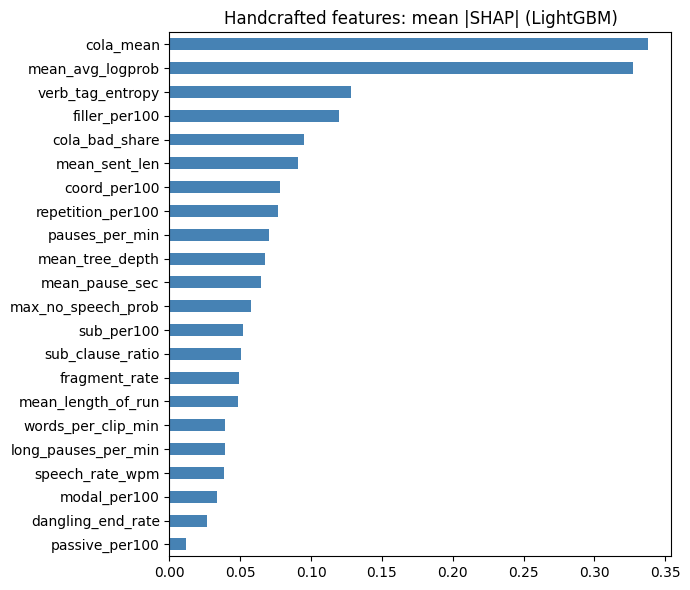

In [9]:
oof_feat = cv_predict("lgb", X_feat[is_train])
record("Step 1: LightGBM, handcrafted features", oof_feat)

ablation = {"all features": RESULTS["Step 1: LightGBM, handcrafted features"]["RMSE"]}
for group, cols in FEATURE_GROUPS.items():
    keep = [i for i, f in enumerate(FEATURES) if f not in cols]
    ablation[f"without {group}"] = score(y, cv_predict("lgb", X_feat[is_train][:, keep]))["RMSE"]
ablation = pd.Series(ablation, name="CV RMSE").to_frame()
ablation["change"] = ablation["CV RMSE"] - ablation.loc["all features", "CV RMSE"]
display(ablation.round(4))
print("Largest loss when removed:", ablation["change"].drop("all features").idxmax())

feat_model = make_model("lgb").fit(X_feat[is_train], y)
shap = np.abs(feat_model.predict(X_feat[is_train], pred_contrib=True)[:, :-1]).mean(axis=0)
pd.Series(shap, index=FEATURES).sort_values().plot.barh(figsize=(7, 6), color="steelblue")
plt.title("Handcrafted features: mean |SHAP| (LightGBM)")
plt.tight_layout()
plt.show()

The features explain only part of the score. Whisper's own confidence (`mean_avg_logprob`) carries much of it: it separates unusable recordings and tracks how clearly people speak. The next steps add learned representations.

## 5. Step 2: transcript embedding (RoBERTa)
RoBERTa's hidden states for the verbatim transcript, averaged over tokens and layers, then a ridge regression. This captures the overall character of the language (restarts, chained clauses) that the features measure only partly.

In [10]:
from transformers import AutoModel

text_tok = AutoTokenizer.from_pretrained("roberta-base")
text_model = AutoModel.from_pretrained("roberta-base").to(DEVICE).eval()

@torch.no_grad()
def embed_texts(texts, batch_size=16):
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc="RoBERTa"):
        batch = text_tok(texts[i:i + batch_size], padding=True, truncation=True, max_length=512,
                         return_tensors="pt").to(DEVICE)
        hidden = torch.stack(text_model(**batch, output_hidden_states=True).hidden_states[1:])
        mask = batch["attention_mask"][None, :, :, None].float()
        out.append(((hidden * mask).sum(dim=2) / mask.sum(dim=2).clamp(min=1)).mean(dim=0).float().cpu().numpy())
    return np.vstack(out)

X_text = embed_texts(data["transcript"].tolist())
del text_model
assert X_text.shape[0] == len(data) and np.isfinite(X_text).all()
oof_text = cv_predict("ridge", X_text[is_train])
record("Step 2: Ridge, RoBERTa transcript embedding", oof_text)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa:   0%|          | 0/62 [00:00<?, ?it/s]

Step 2: Ridge, RoBERTa transcript embedding: CV RMSE 0.9092 | Pearson 0.6789


Still weak on its own: a transcript loses how the speech sounded.

## 6. Step 3: audio embedding (WavLM-large)
WavLM-large (notebook 02) gives, per clip and per layer, the mean and standard deviation of its frame representations over time. Layers are checked individually; a contiguous range of good layers replaces the all-layer average only if it is clearly better (by more than 0.005 RMSE).

In [11]:
def load_embeddings(pattern):
    z = np.load(find_one(pattern))
    row = {k: i for i, k in enumerate(zip(z["split"].tolist(), z["file_id"].tolist()))}
    assert len(row) == len(z["file_id"]), f"Duplicate clips in {pattern}"
    keys = list(zip(data["split"], data["file_id"]))
    missing = [k for k in keys if k not in row]
    assert not missing, f"{len(missing)} clips missing from {pattern}, e.g. {missing[:3]}"
    emb = z["emb"][np.array([row[k] for k in keys])]
    assert np.isfinite(emb).all()
    return emb

def layer_scores(emb, layers):
    return pd.Series({l: score(y, cv_predict("ridge", emb[is_train, l, :].astype(np.float32)))["RMSE"]
                      for l in tqdm(layers, desc="Per-layer CV")}, name="CV RMSE")

def best_layer_range(scores):
    good = scores <= scores.min() + LAYER_TOLERANCE
    lo = hi = int(scores.idxmin())
    while lo - 1 in good.index and good[lo - 1]:
        lo -= 1
    while hi + 1 in good.index and good[hi + 1]:
        hi += 1
    return list(range(lo, hi + 1))

wavlm = load_embeddings("audio_embeddings_*.npz")  # (clips, CNN output + transformer layers, [mean | std])
wavlm_scores = layer_scores(wavlm, range(1, wavlm.shape[1]))
X_wavlm = wavlm[:, 1:, :].astype(np.float32).mean(axis=1)
all_layers = score(y, cv_predict("ridge", X_wavlm[is_train]))["RMSE"]
wavlm_range = best_layer_range(wavlm_scores)
candidate = wavlm[:, wavlm_range, :].astype(np.float32).mean(axis=1)
range_rmse = score(y, cv_predict("ridge", candidate[is_train]))["RMSE"]
print(f"All layers: {all_layers:.4f} | layers {wavlm_range[0]}-{wavlm_range[-1]}: {range_rmse:.4f}")
if range_rmse < all_layers - 0.005:
    X_wavlm = candidate
    print(f"Using layers {wavlm_range[0]}-{wavlm_range[-1]}")
else:
    print("Keeping the all-layer average")
del wavlm, candidate
oof_wavlm = cv_predict("ridge", X_wavlm[is_train])
record("Step 3: Ridge, WavLM-large audio embedding", oof_wavlm)

Per-layer CV:   0%|          | 0/24 [00:00<?, ?it/s]

All layers: 0.5415 | layers 19-21: 0.5351
Using layers 19-21
Step 3: Ridge, WavLM-large audio embedding: CV RMSE 0.5351 | Pearson 0.9020


The audio embedding has far lower error than anything text-based: the raters' grammar scores follow how the speech sounds (pronunciation, rhythm, hesitation) as much as the words.

## 7. Step 4: one model on all inputs, blended with the audio ridge
LightGBM on the 22 features plus the WavLM and RoBERTa embeddings. Trees and ridge use the same audio information differently, so their errors only partly overlap and averaging them cancels part of each. PCA-compressed embeddings were also tried as input and were worse (Section 10).

In [12]:
X_concat = np.hstack([X_feat, X_wavlm, X_text])
oof_concat = cv_predict("lgb", X_concat[is_train])
record("Step 4a: LightGBM, features + WavLM + RoBERTa", oof_concat)
print(f"Error correlation with the WavLM ridge: {np.corrcoef(oof_concat - y, oof_wavlm - y)[0, 1]:.3f}")
record("Step 4b: Blend of WavLM ridge + LightGBM (equal weights)", blend([oof_wavlm, oof_concat]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Step 4a: LightGBM, features + WavLM + RoBERTa: CV RMSE 0.5365 | Pearson 0.9029
Error correlation with the WavLM ridge: 0.868
Step 4b: Blend of WavLM ridge + LightGBM (equal weights): CV RMSE 0.5178 | Pearson 0.9098


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Step 5: a second audio view (Whisper encoder) and the final blend
Whisper-large-v3's encoder (notebook 03) was trained to recognise words, so it represents speech closer to its linguistic content than WavLM does. Its middle-upper layers are selected by per-layer cross-validation. It enters as its own ridge and as an extra input to the LightGBM. The final model is the **equal-weight average of four models**; no weights are tuned.

Per-layer CV:   0%|          | 0/33 [00:00<?, ?it/s]

Whisper layers 18-22
Step 5a: Ridge, Whisper encoder embedding: CV RMSE 0.5738 | Pearson 0.8867


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Step 5b: LightGBM, features + WavLM + RoBERTa + Whisper: CV RMSE 0.5409 | Pearson 0.9006


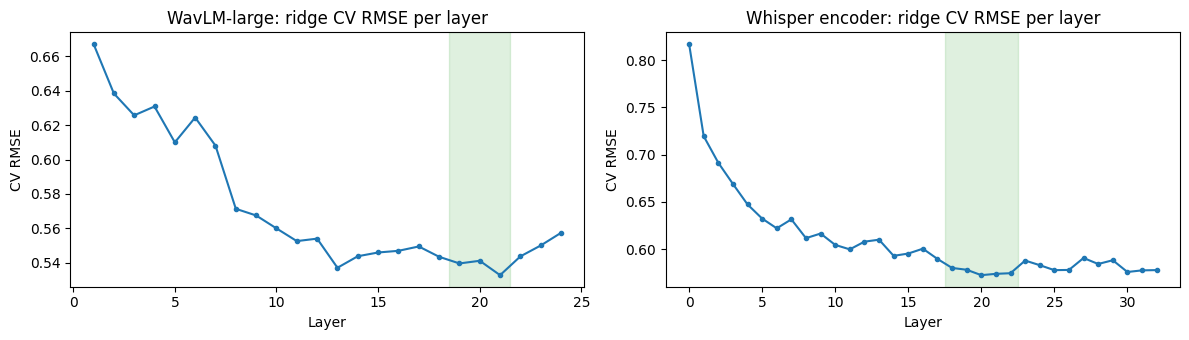

In [13]:
whisper = load_embeddings("whisper_embeddings_*.npz")
whisper_scores = layer_scores(whisper, range(whisper.shape[1]))
whisper_range = best_layer_range(whisper_scores)
X_whisper = whisper[:, whisper_range, :].astype(np.float32).mean(axis=1)
del whisper
print(f"Whisper layers {whisper_range[0]}-{whisper_range[-1]}")
oof_whisper = cv_predict("ridge", X_whisper[is_train])
record("Step 5a: Ridge, Whisper encoder embedding", oof_whisper)
X_concat_w = np.hstack([X_concat, X_whisper])
oof_concat_w = cv_predict("lgb", X_concat_w[is_train])
record("Step 5b: LightGBM, features + WavLM + RoBERTa + Whisper", oof_concat_w)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, s, rng, name in [(axes[0], wavlm_scores, wavlm_range, "WavLM-large"), (axes[1], whisper_scores, whisper_range, "Whisper encoder")]:
    ax.plot(s.index, s.values, marker="o", ms=3)
    ax.axvspan(rng[0] - 0.5, rng[-1] + 0.5, color="tab:green", alpha=0.15)
    ax.set(title=f"{name}: ridge CV RMSE per layer", xlabel="Layer", ylabel="CV RMSE")
plt.tight_layout()
plt.show()

In [14]:
MODELS = {
    "ridge_wavlm": ("ridge", X_wavlm, oof_wavlm),
    "ridge_whisper": ("ridge", X_whisper, oof_whisper),
    "lgb_concat": ("lgb", X_concat, oof_concat),
    "lgb_concat_whisper": ("lgb", X_concat_w, oof_concat_w),
}
oof_final = blend([m[2] for m in MODELS.values()])
record("Step 5c: FINAL, equal-weight blend of the four models", oof_final)

errors = pd.DataFrame({n: m[2] - y for n, m in MODELS.items()})
print("Correlation between the models' errors:")
display(errors.corr().round(3))
loo = {f"without {n}": score(y, blend([m[2] for k, m in MODELS.items() if k != n]))["RMSE"] for n in MODELS}
loo = pd.Series(loo, name="CV RMSE").to_frame()
loo["change"] = loo["CV RMSE"] - RESULTS["Step 5c: FINAL, equal-weight blend of the four models"]["RMSE"]
display(loo.round(4))

Step 5c: FINAL, equal-weight blend of the four models: CV RMSE 0.5144 | Pearson 0.9118
Correlation between the models' errors:


,ridge_wavlm,ridge_whisper,lgb_concat,lgb_concat_whisper
ridge_wavlm,1.000,0.825,0.868,0.858
ridge_whisper,0.825,1.000,0.785,0.820
lgb_concat,0.868,0.785,1.000,0.938
lgb_concat_whisper,0.858,0.820,0.938,1.000


,CV RMSE,change
without ridge_wavlm,0.5214,0.0069
without ridge_whisper,0.5171,0.0026
without lgb_concat,0.5186,0.0041
without lgb_concat_whisper,0.5155,0.0011


The models' errors are correlated but well below 1, which is what makes averaging them useful. The leave-one-out table shows each model's contribution to the blend.

## 9. Final model, training RMSE and submission
Each model is refitted on all training clips. The training RMSE (compulsory) is measured on those same clips and is optimistic by construction; the cross-validated RMSE is the realistic estimate. Because the test set is mostly short clips, the CV error is also reported per clip length and reweighted to the test mix.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


TRAINING RMSE (in-sample): 0.1815 | Pearson 0.9909
5-fold CV RMSE: 0.5144 | Pearson 0.9118 | Spearman 0.8726
CV RMSE reweighted to the test mix (69% short clips): 0.5591


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,clips,RMSE,MAE,R2,Pearson,Spearman
short,182.0,0.5877,0.4706,0.6499,0.8202,0.7743
long,587.0,0.4895,0.3735,0.8571,0.9287,0.8938


,RMSE,MAE,R2,Pearson,Spearman,QWK,Exact (0.5 grid),Within ±0.5,Within ±1.0
Baseline (training mean),1.2382,0.9964,-0.0001,-0.0096,-0.0068,0.0000,0.0832,0.3095,0.5735
Best single model (WavLM ridge),0.5351,0.4017,0.8132,0.9020,0.8539,0.8889,0.4148,0.6918,0.9298
Final blend,0.5144,0.3965,0.8274,0.9118,0.8726,0.8962,0.4213,0.6801,0.9415


,RMSE,MAE,R2,Pearson,Spearman
mean,0.5140,0.3965,0.8275,0.9133,0.8746
std,0.0253,0.0247,0.0140,0.0069,0.0099
min,0.4783,0.3655,0.8157,0.9066,0.8660
max,0.5447,0.4290,0.8470,0.9225,0.8893


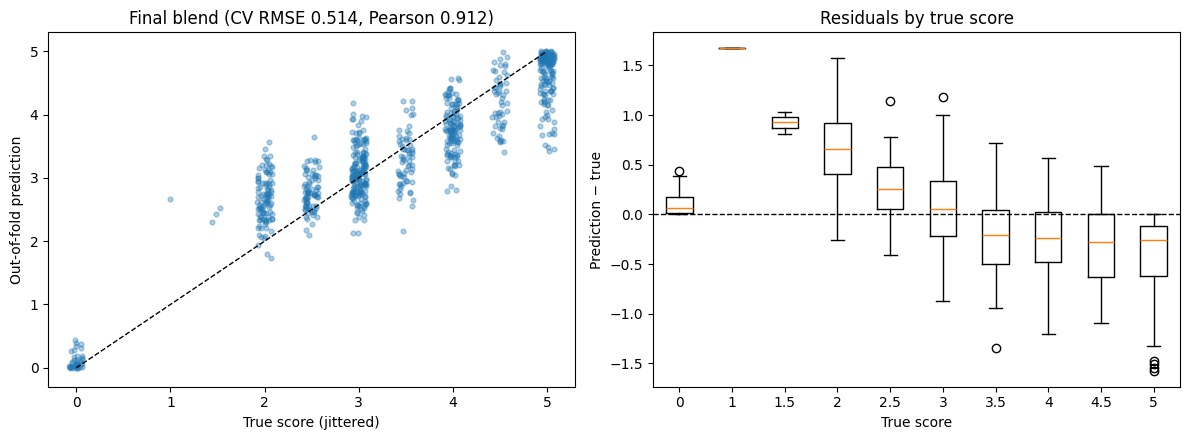

In [15]:
train_parts, test_parts = [], []
for name, (kind, X, _) in MODELS.items():
    model = make_model(kind).fit(X[is_train], y)
    train_parts.append(model.predict(X[is_train]))
    test_parts.append(model.predict(X[is_test]))
train_pred, test_pred = blend(train_parts), blend(test_parts)

cv = RESULTS["Step 5c: FINAL, equal-weight blend of the four models"]
train_scores = score(y, train_pred)
groups = data.loc[is_train, "dur_group"].to_numpy()
by_group = pd.DataFrame({g: {"clips": int((groups == g).sum()), **score(y[groups == g], oof_final[groups == g])}
                         for g in ["short", "long"]}).T
w_short = float((data.loc[is_test, "dur_group"] == "short").mean())
test_mix_rmse = float(np.sqrt(w_short * by_group.loc["short", "RMSE"] ** 2 + (1 - w_short) * by_group.loc["long", "RMSE"] ** 2))
print(f"TRAINING RMSE (in-sample): {train_scores['RMSE']:.4f} | Pearson {train_scores['Pearson']:.4f}")
print(f"5-fold CV RMSE: {cv['RMSE']:.4f} | Pearson {cv['Pearson']:.4f} | Spearman {cv['Spearman']:.4f}")
print(f"CV RMSE reweighted to the test mix ({w_short:.0%} short clips): {test_mix_rmse:.4f}")
display(by_group.round(4))

bench = {"Baseline (training mean)": baseline, "Best single model (WavLM ridge)": oof_wavlm, "Final blend": oof_final}
display(pd.DataFrame({k: {**score(y, v), **agreement(y, v)} for k, v in bench.items()}).T.round(4))
per_fold = pd.DataFrame([score(y[va], oof_final[va]) for _, va in FOLDS], index=[f"fold {i + 1}" for i in range(N_FOLDS)])
display(per_fold.agg(["mean", "std", "min", "max"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y + np.random.uniform(-0.08, 0.08, len(y)), oof_final, alpha=0.35, s=12)
axes[0].plot([0, 5], [0, 5], "k--", lw=1)
axes[0].set(xlim=(-0.3, 5.3), ylim=(-0.3, 5.3), xlabel="True score (jittered)", ylabel="Out-of-fold prediction",
            title=f"Final blend (CV RMSE {cv['RMSE']:.3f}, Pearson {cv['Pearson']:.3f})")
levels = np.unique(y)
axes[1].boxplot([oof_final[y == v] - v for v in levels])
axes[1].set_xticks(range(1, len(levels) + 1), [f"{v:g}" for v in levels])
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set(xlabel="True score", ylabel="Prediction − true", title="Residuals by true score")
plt.tight_layout()
plt.show()

In [16]:
pred_by_id = dict(zip(data.loc[is_test, "file_id"], test_pred))
submission = test_csv[["filename"]].copy()
submission["label"] = submission["filename"].map(lambda s: pred_by_id[Path(s).stem])
assert len(submission) == len(test_csv) and submission["label"].notna().all()
assert submission["label"].between(0, 5).all()
submission.to_csv(OUT_DIR / "submission.csv", index=False)
print(f"Saved submission.csv ({len(submission)} rows)")
display(submission.describe().round(3).T)

Saved submission.csv (216 rows)


,count,mean,std,min,25%,50%,75%,max
label,216.0,3.327,0.752,1.843,2.746,3.21,3.811,4.984


Predictions are pulled towards the middle: low scores are over-predicted and high scores under-predicted, as expected for a regression trained on 769 clips with a crowded centre. Short clips are predicted less accurately than long ones, which matters because they dominate the test set.

## 10. Progression and experiments

,RMSE,MAE,R2,Pearson,Spearman
"Step (computed above, same folds)",,,,,
Baseline: predict the training mean,1.2382,0.9964,-0.0001,-0.0096,-0.0068
"Step 1: LightGBM, handcrafted features",1.0272,0.7929,0.3117,0.5696,0.5511
"Step 2: Ridge, RoBERTa transcript embedding",0.9092,0.6536,0.4608,0.6789,0.7391
"Step 3: Ridge, WavLM-large audio embedding",0.5351,0.4017,0.8132,0.9020,0.8539
"Step 4a: LightGBM, features + WavLM + RoBERTa",0.5365,0.4129,0.8122,0.9029,0.8604
Step 4b: Blend of WavLM ridge + LightGBM (equal weights),0.5178,0.3951,0.8251,0.9098,0.8679
"Step 5a: Ridge, Whisper encoder embedding",0.5738,0.4409,0.7853,0.8867,0.8365
"Step 5b: LightGBM, features + WavLM + RoBERTa + Whisper",0.5409,0.4145,0.8091,0.9006,0.8551
"Step 5c: FINAL, equal-weight blend of the four models",0.5144,0.3965,0.8274,0.9118,0.8726


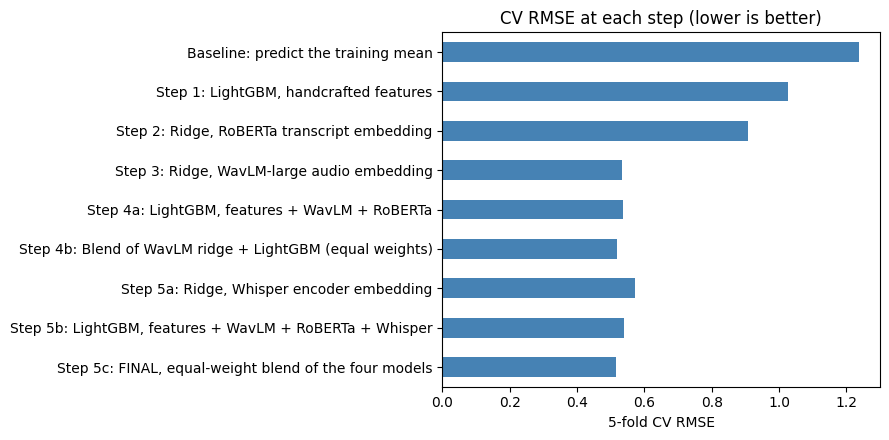

In [17]:
table = pd.DataFrame(RESULTS).T[["RMSE", "MAE", "R2", "Pearson", "Spearman"]]
table.index.name = "Step (computed above, same folds)"
display(table.round(4))
ax = table["RMSE"].iloc[::-1].plot.barh(figsize=(9, 4.5), color="steelblue")
ax.set(xlabel="5-fold CV RMSE", ylabel="", title="CV RMSE at each step (lower is better)")
plt.tight_layout()
plt.show()

**Submission history** (recorded at the time of each submission; earlier versions used inputs since replaced):

| Version | CV RMSE | Public LB RMSE |
| :--- | :--- | :--- |
| LightGBM on handcrafted features (LanguageTool for accuracy) | 1.0760 | 0.7220 |
| Ridge on WavLM-base audio embedding | 0.5637 | 0.4742 |
| + RoBERTa text ridge (weighted blend) | 0.5518 | 0.4382 |
| WavLM-base ridge + combined LightGBM (50/50) | 0.5373 | 0.4329 |
| + Whisper encoder models (four-model blend) | 0.5249 | 0.4096 |
| WavLM-large instead of WavLM-base (final) | 0.5147 | **0.3882** |

**Tried and dropped** (recorded results, same folds):

| Experiment | Result | Decision |
| :--- | :--- | :--- |
| LanguageTool error rates for accuracy | Median 0 errors per transcript; removing the group changed RMSE by 0.008 | Replaced by CoLA (feature model 1.076 → 1.027) |
| PCA-compressed embeddings in LightGBM (16/32/64 dims) | 0.572 / 0.559 / 0.564 vs 0.546 with raw embeddings | Raw embeddings kept |
| WavLM-base, best layer range only (10–11) | 0.574 vs 0.564 with all layers | All layers kept |
| CrisperWhisper encoder (verbatim fine-tune of Whisper) | 0.579 alone; not selected in any best blend | Dropped: same encoder behaviour as Whisper |
| LLM grader (Qwen2.5-7B with the rubric): grades / transcript embedding | 1.065 / 0.873 alone; not selected in any best blend | Dropped: errors overlap with the audio models |
| Training without label-0 clips | Not evaluated: could only be validated on the leaderboard | Not used |

## 11. Limitations
- **Speaker overlap was not verified.** If the same speakers recorded several training clips, random folds let audio models partly recognise voices and the CV RMSE is optimistic for new speakers. Speaker-grouped folds were not adopted because every CV improvement here also improved the leaderboard, and the leaderboard RMSE (0.388) is lower than the CV RMSE.
- **Short clips** (69% of the test set) are predicted less accurately (see Section 9); training on 45 s crops of the long clips is the most direct next step.
- **Transcripts** inherit Whisper's errors, and the LightGBM settings were fixed, not tuned.